## Importación de librerías

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import cv2
from skimage.feature import hog
from skimage import exposure
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import albumentations as A
from tqdm import tqdm
import joblib
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import models, transforms
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Configuración de rutas y parámetros

In [3]:
ruta_base = Path(r'e:\06. Sexto Ciclo\01. Machine Learning\07. Workspace\16S03. Proyecto 03\P3-EcoSort')
ruta_train = ruta_base / 'data' / 'preprocessed' / 'train'
ruta_val = ruta_base / 'data' / 'preprocessed' / 'val'
ruta_features = ruta_base / 'result' / 'features'
ruta_figuras = ruta_base / 'result' / 'figures'

clases = ['general', 'paper', 'plastic']
etiquetas_map = {'general': 0, 'paper': 1, 'plastic': 2}

tamanio_imagen = (128, 128)
objetivo_train = 10000

## 1. Normalización y preprocesamiento

### 1.1 Función de carga y normalización

In [4]:
def cargar_y_normalizar_imagen(ruta_imagen, tamanio):
    img = cv2.imread(str(ruta_imagen))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, tamanio)
    img_normalizada = img.astype(np.float32) / 255.0
    return img_normalizada, img


## 2. Data Augmentation

### 2.1 Configuración de transformaciones

In [5]:
transformaciones = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    A.GaussNoise(var_limit=(10.0, 30.0), p=0.3),
    A.Blur(blur_limit=3, p=0.2)
])

### 2.2 Función de augmentación

In [6]:
def aplicar_augmentation(imagen):
    imagen_uint8 = (imagen * 255).astype(np.uint8)
    augmentada = transformaciones(image=imagen_uint8)
    imagen_augmentada = augmentada['image'].astype(np.float32) / 255.0
    return imagen_augmentada

### 2.3 Visualización de augmentation

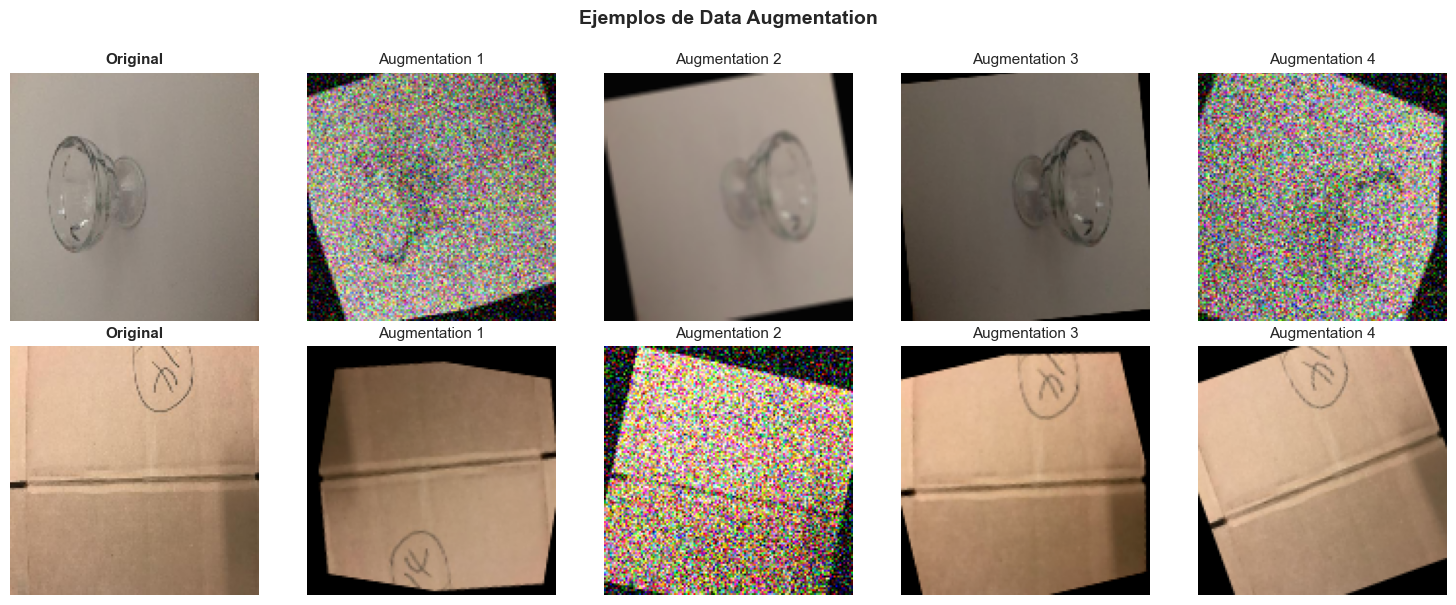

In [7]:
archivos_ejemplo = list((ruta_train / 'general').glob('*.jpg'))
img_original, img_original_uint8 = cargar_y_normalizar_imagen(archivos_ejemplo[0], tamanio_imagen)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(img_original)
axes[0, 0].set_title('Original', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

for i in range(1, 5):
    img_aug = aplicar_augmentation(img_original)
    axes[0, i].imshow(img_aug)
    axes[0, i].set_title(f'Augmentation {i}', fontsize=11)
    axes[0, i].axis('off')

archivos_ejemplo = list((ruta_train / 'paper').glob('*.jpg'))
img_original, img_original_uint8 = cargar_y_normalizar_imagen(archivos_ejemplo[0], tamanio_imagen)

axes[1, 0].imshow(img_original)
axes[1, 0].set_title('Original', fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

for i in range(1, 5):
    img_aug = aplicar_augmentation(img_original)
    axes[1, i].imshow(img_aug)
    axes[1, i].set_title(f'Augmentation {i}', fontsize=11)
    axes[1, i].axis('off')

plt.suptitle('Ejemplos de Data Augmentation', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(ruta_figuras / '02_fe_01_augmentation_ejemplos.svg', format='svg', bbox_inches='tight')
plt.show()

### 2.4 Generación de dataset aumentado

In [8]:
def generar_dataset_aumentado(ruta_dataset, objetivo_total, aplicar_aug=True):
    imagenes = []
    etiquetas = []
    
    for clase in clases:
        ruta_clase = ruta_dataset / clase
        archivos = list(ruta_clase.glob('*.jpg')) + list(ruta_clase.glob('*.jpeg')) + list(ruta_clase.glob('*.png'))
        
        num_originales = len(archivos)
        objetivo_por_clase = objetivo_total // len(clases)
        num_augmentaciones = max(0, objetivo_por_clase - num_originales)
        
        for archivo in tqdm(archivos, desc=f'Cargando {clase}'):
            try:
                img_norm, _ = cargar_y_normalizar_imagen(archivo, tamanio_imagen)
                imagenes.append(img_norm)
                etiquetas.append(etiquetas_map[clase])
            except Exception as e:
                continue
        
        if aplicar_aug and num_augmentaciones > 0:
            for _ in tqdm(range(num_augmentaciones), desc=f'Augmentation {clase}'):
                archivo_random = np.random.choice(archivos)
                try:
                    img_norm, _ = cargar_y_normalizar_imagen(archivo_random, tamanio_imagen)
                    img_aug = aplicar_augmentation(img_norm)
                    imagenes.append(img_aug)
                    etiquetas.append(etiquetas_map[clase])
                except Exception as e:
                    continue
    
    return np.array(imagenes), np.array(etiquetas)

X_train, y_train = generar_dataset_aumentado(ruta_train, objetivo_train, aplicar_aug=True)
X_val, y_val = generar_dataset_aumentado(ruta_val, objetivo_total=5000, aplicar_aug=False)

Cargando plastic: 100%|██████████| 97/97 [00:00<00:00, 584.28it/s]


In [9]:
resumen_dataset = pd.DataFrame({
    'Dataset': ['Train', 'Val'],
    'Total imágenes': [len(X_train), len(X_val)],
    'Shape': [str(X_train.shape), str(X_val.shape)]
})
resumen_dataset

,Dataset,Total imágenes,Shape
0,Train,9999,"(9999, 128, 128, 3)"
1,Val,507,"(507, 128, 128, 3)"


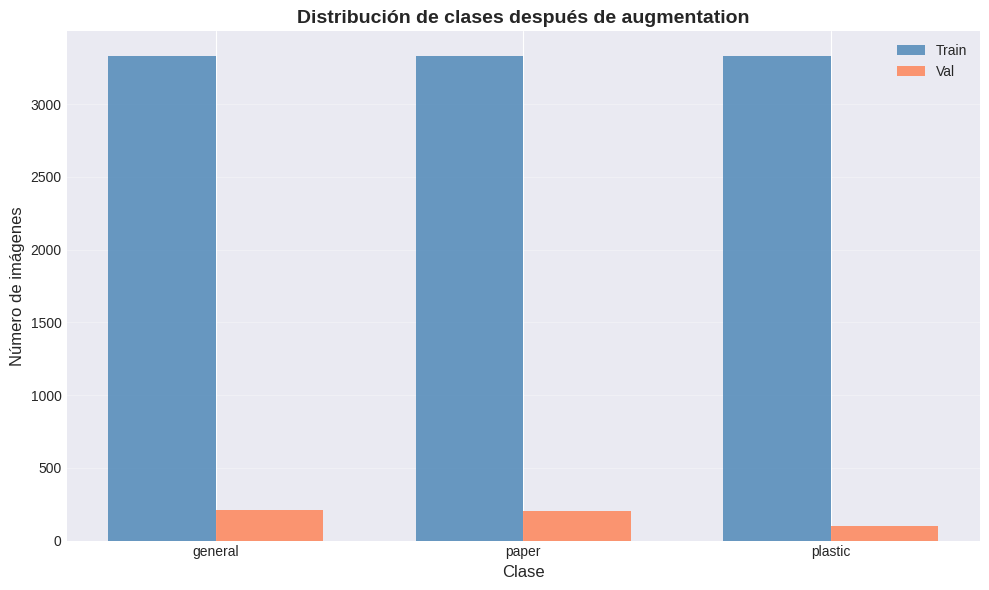

In [10]:
distribucion_train = pd.Series(y_train).value_counts().sort_index()
distribucion_val = pd.Series(y_val).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(clases))
ancho = 0.35

ax.bar(x - ancho/2, distribucion_train.values, ancho, label='Train', alpha=0.8, color='steelblue')
ax.bar(x + ancho/2, distribucion_val.values, ancho, label='Val', alpha=0.8, color='coral')

ax.set_xlabel('Clase', fontsize=12)
ax.set_ylabel('Número de imágenes', fontsize=12)
ax.set_title('Distribución de clases después de augmentation', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(clases)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ruta_figuras / '02_fe_02_distribucion_post_augmentation.svg', format='svg', bbox_inches='tight')
plt.show()

## 3. Extracción de características

### 3.1 Extracción de características HOG

In [11]:
def extraer_hog(imagen):
    imagen_gris = cv2.cvtColor((imagen * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    features_hog = hog(
        imagen_gris,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False,
        feature_vector=True
    )
    return features_hog

### 3.2 Visualización de HOG

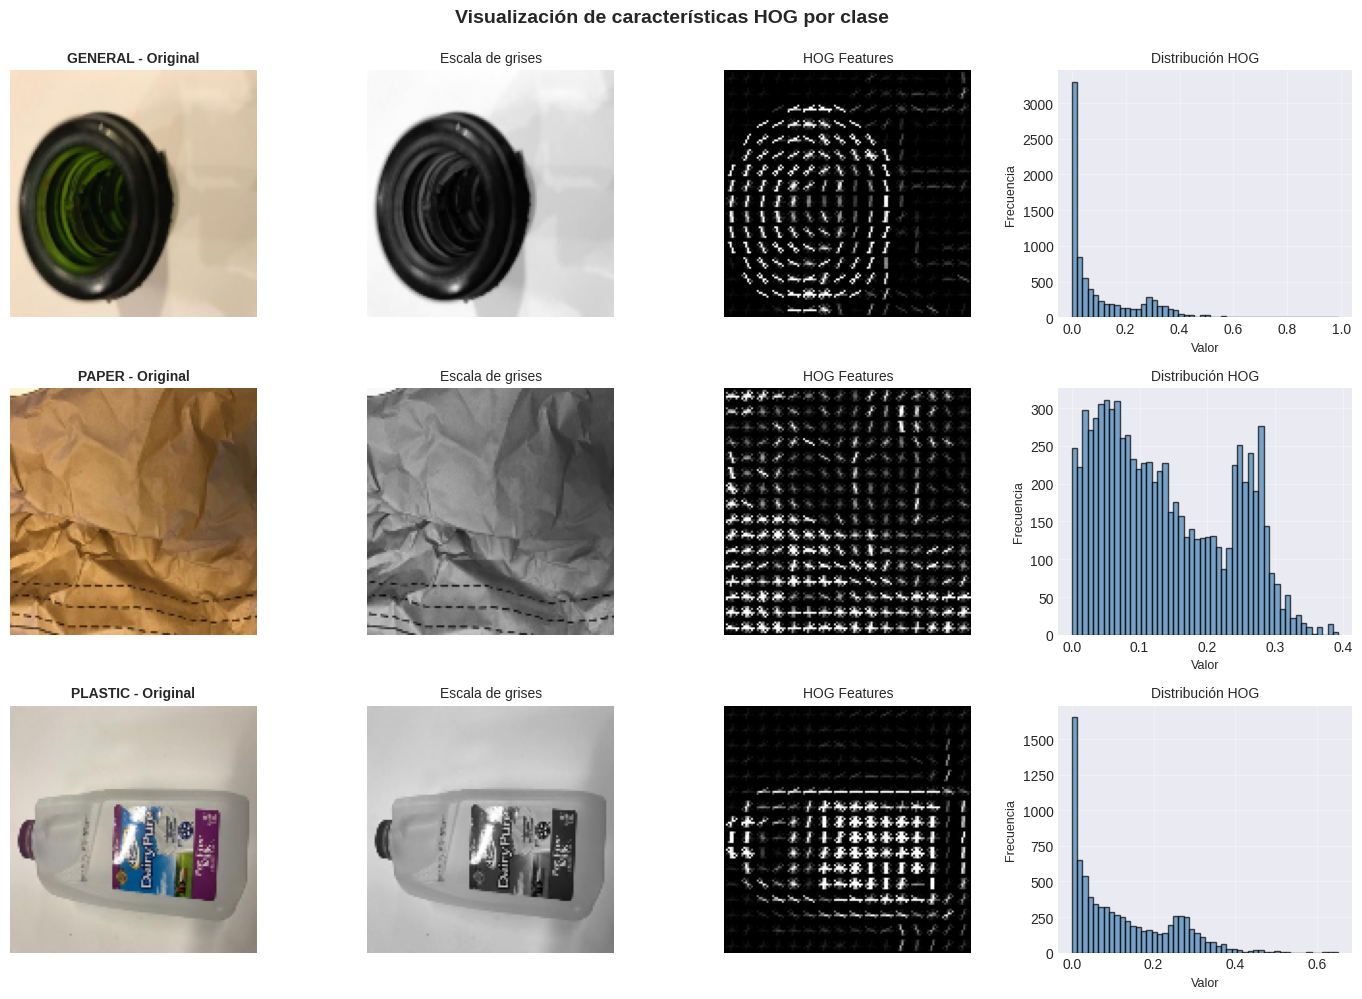

In [12]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for i, clase in enumerate(clases):
    idx_clase = np.where(y_train == etiquetas_map[clase])[0][0]
    img = X_train[idx_clase]
    img_gris = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
    
    features_hog, hog_image = hog(
        img_gris,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=True,
        feature_vector=True
    )
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'{clase.upper()} - Original', fontsize=10, fontweight='bold')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(img_gris, cmap='gray')
    axes[i, 1].set_title('Escala de grises', fontsize=10)
    axes[i, 1].axis('off')
    
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    axes[i, 2].imshow(hog_image_rescaled, cmap='gray')
    axes[i, 2].set_title('HOG Features', fontsize=10)
    axes[i, 2].axis('off')
    
    axes[i, 3].hist(features_hog, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[i, 3].set_title('Distribución HOG', fontsize=10)
    axes[i, 3].set_xlabel('Valor', fontsize=9)
    axes[i, 3].set_ylabel('Frecuencia', fontsize=9)
    axes[i, 3].grid(alpha=0.3)

plt.suptitle('Visualización de características HOG por clase', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(ruta_figuras / '02_fe_03_hog_visualizacion.svg', format='svg', bbox_inches='tight')
plt.show()

### 3.3 Extracción de características de color

In [13]:
def extraer_caracteristicas_color(imagen):
    img_uint8 = (imagen * 255).astype(np.uint8)
    
    hist_rgb = []
    for canal in range(3):
        hist = cv2.calcHist([img_uint8], [canal], None, [32], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        hist_rgb.extend(hist)
    
    img_hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)
    hist_hsv = []
    for canal in range(3):
        hist = cv2.calcHist([img_hsv], [canal], None, [32], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        hist_hsv.extend(hist)
    
    img_lab = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
    hist_lab = []
    for canal in range(3):
        hist = cv2.calcHist([img_lab], [canal], None, [32], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        hist_lab.extend(hist)
    
    momentos_rgb = []
    for canal in range(3):
        momentos = cv2.moments(img_uint8[:, :, canal])
        momentos_rgb.extend([momentos['mu20'], momentos['mu11'], momentos['mu02']])
    
    features_color = np.concatenate([hist_rgb, hist_hsv, hist_lab, momentos_rgb])
    return features_color

### 3.4 Visualización de características de color

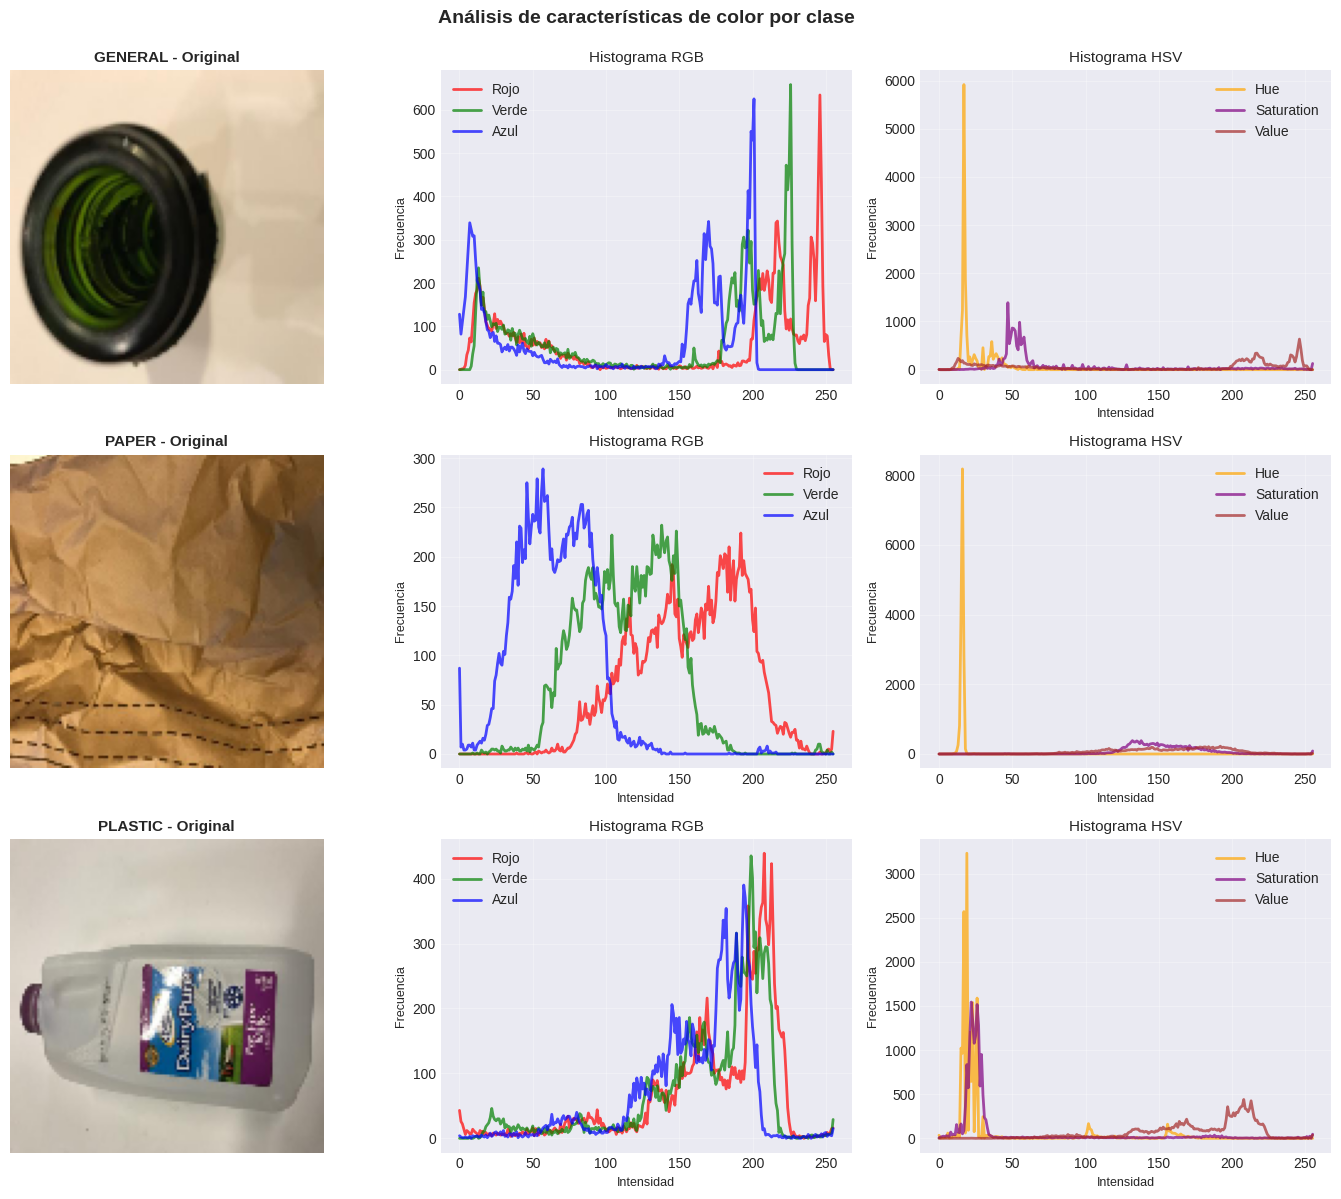

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, clase in enumerate(clases):
    idx_clase = np.where(y_train == etiquetas_map[clase])[0][0]
    img = X_train[idx_clase]
    img_uint8 = (img * 255).astype(np.uint8)
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'{clase.upper()} - Original', fontsize=11, fontweight='bold')
    axes[i, 0].axis('off')
    
    colores = ('r', 'g', 'b')
    nombres_canales = ('Rojo', 'Verde', 'Azul')
    for j, (color, nombre) in enumerate(zip(colores, nombres_canales)):
        hist = cv2.calcHist([img_uint8], [j], None, [256], [0, 256])
        axes[i, 1].plot(hist, color=color, label=nombre, alpha=0.7, linewidth=2)
    axes[i, 1].set_title('Histograma RGB', fontsize=11)
    axes[i, 1].set_xlabel('Intensidad', fontsize=9)
    axes[i, 1].set_ylabel('Frecuencia', fontsize=9)
    axes[i, 1].legend()
    axes[i, 1].grid(alpha=0.3)
    
    img_hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)
    colores_hsv = ('orange', 'purple', 'brown')
    nombres_hsv = ('Hue', 'Saturation', 'Value')
    for j, (color, nombre) in enumerate(zip(colores_hsv, nombres_hsv)):
        hist = cv2.calcHist([img_hsv], [j], None, [256], [0, 256])
        axes[i, 2].plot(hist, color=color, label=nombre, alpha=0.7, linewidth=2)
    axes[i, 2].set_title('Histograma HSV', fontsize=11)
    axes[i, 2].set_xlabel('Intensidad', fontsize=9)
    axes[i, 2].set_ylabel('Frecuencia', fontsize=9)
    axes[i, 2].legend()
    axes[i, 2].grid(alpha=0.3)

plt.suptitle('Análisis de características de color por clase', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(ruta_figuras / '02_fe_04_color_visualizacion.svg', format='svg', bbox_inches='tight')
plt.show()

### 3.5  Extracción con transfer learning

In [15]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")


class TransferLearningFeatureExtractor:
    def __init__(self, model_name='resnet18', device=None):
        self.model_name = model_name
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None
        self.feature_dim = None
        self.transform = None

        self._build_model()

    def _build_model(self):

        print(f"argando modelo preentrenado: {self.model_name}")

        if self.model_name == 'resnet18':
            base_model = models.resnet18(pretrained=True)
            self.model = nn.Sequential(*list(base_model.children())[:-1])  
            self.feature_dim = 512

        elif self.model_name == 'resnet50':
            base_model = models.resnet50(pretrained=True)
            self.model = nn.Sequential(*list(base_model.children())[:-1])
            self.feature_dim = 2048

        elif self.model_name == 'efficientnet_b0':
            base_model = models.efficientnet_b0(pretrained=True)
            self.model = nn.Sequential(*list(base_model.children())[:-1])  
            self.feature_dim = 1280

        elif self.model_name == 'efficientnet_b1':
            base_model = models.efficientnet_b1(pretrained=True)
            self.model = nn.Sequential(*list(base_model.children())[:-1])
            self.feature_dim = 1280

        else:
            raise ValueError(f"Modelo no soportado: {self.model_name}")

        self.model = self.model.to(self.device)
        self.model.eval()

        self.transform = transforms.Compose([
            transforms.Resize(256), 
            transforms.CenterCrop(224), 
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                              std=[0.229, 0.224, 0.225])
        ])

        print(f"Dimension de features: {self.feature_dim}")

    def extract_features(self, images, batch_size=64):
        
        print(f"Extrayendo features con {self.model_name}...")
        print(f"Imágenes de entrada: {images.shape}")
        print(f"Batch size: {batch_size}")

        images_tensor = torch.FloatTensor(images).permute(0, 3, 1, 2)

        images_transformed = []
        for img in images_tensor:
            img_transformed = self.transform(img)
            images_transformed.append(img_transformed)
        images_transformed = torch.stack(images_transformed)

        dataset = TensorDataset(images_transformed)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

        features_list = []

        with torch.no_grad():
            for batch_idx, (batch,) in enumerate(tqdm(loader, desc=f'Extrayendo features')):
                batch = batch.to(self.device)

                batch_features = self.model(batch)

                batch_features = batch_features.view(batch_features.size(0), -1)

                features_list.append(batch_features.cpu().numpy())

        features = np.vstack(features_list)

        print(f"Features extraídas: {features.shape}")

        return features

    def visualize_feature_distribution(self, features, labels, class_names, n_samples=1000):

        pca_viz = PCA(n_components=2, random_state=42)

        if len(features) > n_samples:
            indices = np.random.choice(len(features), n_samples, replace=False)
            features_subset = features[indices]
            labels_subset = labels[indices]
        else:
            features_subset = features
            labels_subset = labels

        features_2d = pca_viz.fit_transform(features_subset)

        fig, ax = plt.subplots(figsize=(10, 7))

        colors = ['steelblue', 'coral', 'lightgreen']
        for i, class_name in enumerate(class_names):
            mask = labels_subset == i
            ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
                      alpha=0.6, label=class_name, s=30,
                      c=colors[i], edgecolors='black', linewidth=0.5)

        ax.set_xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
        ax.set_ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
        ax.set_title(f'Visualización de features {self.model_name} en 2D',
                    fontsize=14, fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()

        return fig



Usando dispositivo: cpu


In [ ]:


def extraer_features_transfer_learning(X_train, X_val, y_train, y_val,
                                      clases=['general', 'paper', 'plastic'],
                                      modelos=['resnet18', 'efficientnet_b0'],
                                      batch_size=64,
                                      guardar=True,
                                      ruta_features=None,
                                      ruta_figuras=None):
    

    resultados = {}

    for modelo_nombre in modelos:
        print(f"\n{'='*70}")
        print(f"Procesando modelo {modelo_nombre.upper()}")
        print(f"{'='*70}\n")

        extractor = TransferLearningFeatureExtractor(model_name=modelo_nombre)

        print("Extrayendo features de train")
        features_train = extractor.extract_features(X_train, batch_size=batch_size)

        print("\nExtrayendo features de val")
        features_val = extractor.extract_features(X_val, batch_size=batch_size)

        resultados[modelo_nombre] = {
            'train': features_train,
            'val': features_val,
            'feature_dim': extractor.feature_dim
        }

        if ruta_figuras is not None:
            print("\nVisualizacion")
            fig = extractor.visualize_feature_distribution(
                features_train, y_train, clases, n_samples=1000
            )
            fig.savefig(
                ruta_figuras / f'02_fe_features_{modelo_nombre}_2d.svg',
                format='svg', bbox_inches='tight'
            )
            plt.show()
            plt.close()

        if guardar and ruta_features is not None:
            print(f"\nGuardando features")
            np.save(ruta_features / f'features_train_{modelo_nombre}.npy', features_train)
            np.save(ruta_features / f'features_val_{modelo_nombre}.npy', features_val)
            print(f"Guardado en: {ruta_features}")

        print(f"\nResumen de features:")
        print(f"Train shape: {features_train.shape}")
        print(f"Val shape: {features_val.shape}")
        print(f"Feature dimension: {extractor.feature_dim}")
        print(f"Train mean: {features_train.mean():.4f} ± {features_train.std():.4f}")
        print(f"Val mean: {features_val.mean():.4f} ± {features_val.std():.4f}")

    resumen_data = []
    for modelo_nombre, datos in resultados.items():
        resumen_data.append({
            'Modelo': modelo_nombre,
            'Dimensiones': datos['feature_dim'],
            'Train Shape': str(datos['train'].shape),
            'Val Shape': str(datos['val'].shape),
            'Memoria (MB)': f"{(datos['train'].nbytes + datos['val'].nbytes) / (1024**2):.2f}"
        })

    resumen_df = pd.DataFrame(resumen_data)

    print(f"\n{'='*70}")
    print("RESUMEN")
    print(f"{'='*70}\n")
    print(resumen_df.to_string(index=False))
    print()

    return resultados, resumen_df

resultados_tl, resumen_tl = extraer_features_transfer_learning(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,
    y_val=y_val,
    clases=clases,
    modelos=['resnet18', 'efficientnet_b0'], 
    batch_size=64,
    guardar=True,
    ruta_features=ruta_features,
    ruta_figuras=ruta_figuras
)

resumen_tl


Procesando modelo RESNET18

argando modelo preentrenado: resnet18
Dimension de features: 512
Extrayendo features de train
Extrayendo features con resnet18...
Imágenes de entrada: (9999, 128, 128, 3)
Batch size: 64


### 3.5  Extracción con autoencoders

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import pandas as pd
from scipy.stats import gaussian_kde
from pathlib import Path


class ConvolutionalAutoencoderMejorado(nn.Module):
    """Autoencoder con cuello de botella menos agresivo"""
    def __init__(self, latent_dim=512):
        super(ConvolutionalAutoencoderMejorado, self).__init__()
        self.latent_dim = latent_dim

        # Encoder - menos compresión
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),   # 64x64
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 32x32
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # 16x16
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1), # 8x8
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
        )

        # FC menos agresivo: 8*8*512 = 32768 → 1024 → latent
        self.encoder_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8 * 8 * 512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, latent_dim)
        )

        # Decoder
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 8 * 8 * 512),
            nn.LeakyReLU(0.2)
        )

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        conv_features = self.encoder_conv(x)
        latent = self.encoder_fc(conv_features)
        return latent

    def decode(self, latent):
        decoded_fc = self.decoder_fc(latent)
        decoded_fc = decoded_fc.view(-1, 512, 8, 8)  # Cambiar a 512
        decoded = self.decoder_conv(decoded_fc)
        return decoded

    def forward(self, x):
        latent = self.encode(x)
        reconstructed = self.decode(latent)
        return reconstructed, latent


def loss_autoencoder_mejorado(recon, original, latent, lambda_var=0.0):
    """Solo MSE - sin regularización"""
    loss_recon = F.mse_loss(recon, original)
    loss_var = torch.tensor(0.0).to(recon.device)
    
    if lambda_var > 0:
        var_per_dim = latent.var(dim=0)
        loss_var = -torch.mean(torch.log(var_per_dim + 1e-8))
    
    total_loss = loss_recon + lambda_var * loss_var
    return total_loss, loss_recon, loss_var


class AutoencoderExtractorMejorado:
    """Extractor con autoencoder mejorado (NO supervisado)"""
    
    def __init__(self, latent_dim=128):
        self.latent_dim = latent_dim
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = None
        self.scaler = StandardScaler()
        self.training_history = {}

    def build_model(self):
        print(f"Construyendo Autoencoder Convolucional Mejorado...")
        print(f"Latent dimension: {self.latent_dim}")

        self.model = ConvolutionalAutoencoderMejorado(self.latent_dim).to(self.device)

        total_params = sum(p.numel() for p in self.model.parameters())
        print(f"Parámetros totales: {total_params:,}")

        return self.model

    def train(self, X_train, X_val, epochs=30, batch_size=64, 
              learning_rate=0.0005, lambda_var=0.01):
        
        print(f"\n{'='*70}")
        print(f"ENTRENANDO AUTOENCODER CONVOLUCIONAL MEJORADO (NO SUPERVISADO)")
        print(f"{'='*70}")
        print(f"Épocas: {epochs} | Batch: {batch_size} | LR: {learning_rate}")
        print(f"Lambda varianza: {lambda_var}")
        print(f"{'='*70}\n")

        if self.model is None:
            self.build_model()

        # Preparar datos (sin etiquetas)
        X_train_tensor = torch.FloatTensor(X_train).permute(0, 3, 1, 2)
        X_val_tensor = torch.FloatTensor(X_val).permute(0, 3, 1, 2)

        train_loader = DataLoader(TensorDataset(X_train_tensor), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_val_tensor), batch_size=batch_size, shuffle=False)

        optimizer = torch.optim.AdamW(self.model.parameters(), lr=learning_rate, weight_decay=0.01)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

        train_losses = []
        val_losses = []
        best_val_loss = float('inf')
        patience_counter = 0
        patience = 10

        for epoch in range(epochs):
            # Training
            self.model.train()
            epoch_losses = []

            pbar = tqdm(train_loader, desc=f'Época {epoch+1}/{epochs}')
            for (data,) in pbar:
                data = data.to(self.device)

                optimizer.zero_grad()
                recon, latent = self.model(data)

                loss, loss_recon, loss_var = loss_autoencoder_mejorado(
                    recon, data, latent, lambda_var
                )

                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                optimizer.step()

                epoch_losses.append(loss.item())
                pbar.set_postfix({
                    'recon': f'{loss_recon.item():.4f}',
                    'var': f'{loss_var.item():.4f}'
                })

            avg_train_loss = np.mean(epoch_losses)
            train_losses.append(avg_train_loss)

            # Validation
            self.model.eval()
            val_loss_list = []

            with torch.no_grad():
                for (data,) in val_loader:
                    data = data.to(self.device)
                    recon, latent = self.model(data)
                    loss, _, _ = loss_autoencoder_mejorado(recon, data, latent, lambda_var)
                    val_loss_list.append(loss.item())

            avg_val_loss = np.mean(val_loss_list)
            val_losses.append(avg_val_loss)

            current_lr = optimizer.param_groups[0]["lr"]
            print(f'Época {epoch+1} - Train: {avg_train_loss:.4f} - Val: {avg_val_loss:.4f} - LR: {current_lr:.6f}')

            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                patience_counter = 0
                torch.save(self.model.state_dict(), 'best_ae_mejorado.pth')
                print(f"✓ Mejor modelo guardado")
            else:
                patience_counter += 1

            scheduler.step(avg_val_loss)

            if patience_counter >= patience:
                print(f"\n⏹ Early stopping en época {epoch+1}")
                break

        self.model.load_state_dict(torch.load('best_ae_mejorado.pth'))

        self.training_history = {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
            'epochs_trained': len(train_losses)
        }

        return self.training_history

    def extract_features(self, X, batch_size=64):
        if self.model is None:
            raise ValueError("Modelo no entrenado")

        self.model.eval()
        X_tensor = torch.FloatTensor(X).permute(0, 3, 1, 2)
        loader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)

        features_list = []
        with torch.no_grad():
            for (data,) in tqdm(loader, desc='Extrayendo features'):
                data = data.to(self.device)
                latent = self.model.encode(data)
                features_list.append(latent.cpu().numpy())

        features = np.vstack(features_list)

        if not hasattr(self.scaler, 'mean_') or self.scaler.mean_ is None:
            features = self.scaler.fit_transform(features)
        else:
            features = self.scaler.transform(features)

        return features

    def visualize_reconstruction(self, X_test, n_samples=5):
        self.model.eval()
        indices = np.random.choice(len(X_test), n_samples, replace=False)
        X_samples = X_test[indices]

        X_tensor = torch.FloatTensor(X_samples).permute(0, 3, 1, 2).to(self.device)

        with torch.no_grad():
            recon, _ = self.model(X_tensor)

        recon = recon.permute(0, 2, 3, 1).cpu().numpy()

        fig, axes = plt.subplots(2, n_samples, figsize=(15, 6))
        for i in range(n_samples):
            axes[0, i].imshow(X_samples[i])
            axes[0, i].set_title('Original')
            axes[0, i].axis('off')

            axes[1, i].imshow(np.clip(recon[i], 0, 1))
            axes[1, i].set_title('Rebuilt')
            axes[1, i].axis('off')

        plt.suptitle('Autoencoder - Image reconstruction', fontweight='bold')
        plt.tight_layout()
        return fig

    def plot_training(self):
        fig, ax = plt.subplots(figsize=(10, 5))

        epochs = range(1, len(self.training_history['train_losses']) + 1)

        ax.plot(epochs, self.training_history['train_losses'], 'b-o', label='Train')
        ax.plot(epochs, self.training_history['val_losses'], 'r-s', label='Val')
        ax.set_xlabel('Época')
        ax.set_ylabel('Loss')
        ax.set_title('Curvas de pérdida - Autoencoder Mejorado')
        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()
        return fig


def extraer_features_ae_mejorado(X_train, X_val, y_train, y_val,
                                  clases=['general', 'paper', 'plastic'],
                                  latent_dim=128,
                                  epochs=30,
                                  batch_size=64,
                                  learning_rate=0.0005,
                                  lambda_var=0.01,
                                  guardar=True,
                                  ruta_features=None,
                                  ruta_figuras=None):
    """Extrae features con autoencoder mejorado (NO supervisado)"""
    
    print(f"\n{'='*70}")
    print(f"AUTOENCODER CONVOLUCIONAL MEJORADO")
    print(f"{'='*70}")

    extractor = AutoencoderExtractorMejorado(latent_dim=latent_dim)

    # Entrenar SIN etiquetas
    history = extractor.train(
        X_train, X_val,
        epochs=epochs,
        batch_size=batch_size,
        learning_rate=learning_rate,
        lambda_var=lambda_var
    )

    # Visualizaciones
    fig_train = extractor.plot_training()
    if ruta_figuras:
        fig_train.savefig(ruta_figuras / 'ae_mejorado_training.svg', bbox_inches='tight')
    plt.show()
    plt.close()

    fig_recon = extractor.visualize_reconstruction(X_val, n_samples=5)
    if ruta_figuras:
        fig_recon.savefig(ruta_figuras / 'ae_mejorado_reconstruction.svg', bbox_inches='tight')
    plt.show()
    plt.close()

    # Extraer features
    print("\nExtrayendo features...")
    features_train = extractor.extract_features(X_train)
    features_val = extractor.extract_features(X_val)

    # Visualización 2D (usa y_train solo para colorear, NO para entrenar)
    pca = PCA(n_components=2, random_state=42)

    indices = []
    for i in range(len(clases)):
        idx_clase = np.where(y_train == i)[0]
        indices.extend(np.random.choice(idx_clase, min(400, len(idx_clase)), replace=False))

    features_2d = pca.fit_transform(features_train[indices])
    y_subset = y_train[indices]

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['steelblue', 'coral', 'lightgreen']

    for i, clase in enumerate(clases):
        mask = y_subset == i
        ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
                  alpha=0.6, label=clase, s=30, c=colors[i],
                  edgecolors='black', linewidth=0.5)

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('Features Autoencoder Mejorado en 2D', fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)

    if ruta_figuras:
        plt.savefig(ruta_figuras / 'ae_mejorado_features_2d.svg', bbox_inches='tight')
    plt.show()
    plt.close()

    # Guardar
    if guardar and ruta_features:
        np.save(ruta_features / 'features_train_ae_mejorado.npy', features_train)
        np.save(ruta_features / 'features_val_ae_mejorado.npy', features_val)
        print(f"Features guardadas en {ruta_features}")

    return {
        'features_train': features_train,
        'features_val': features_val,
        'extractor': extractor,
        'history': history
    }


AUTOENCODER CONVOLUCIONAL MEJORADO

ENTRENANDO AUTOENCODER CONVOLUCIONAL MEJORADO (NO SUPERVISADO)
Épocas: 30 | Batch: 64 | LR: 0.0005
Lambda varianza: 0

Construyendo Autoencoder Convolucional Mejorado...
Latent dimension: 980
Parámetros totales: 74,667,095


Época 1/30: 100%|██████████| 157/157 [00:23<00:00,  6.56it/s, recon=0.0369, var=0.0000]


Época 1 - Train: 0.0495 - Val: 0.0204 - LR: 0.000500
✓ Mejor modelo guardado


Época 2/30: 100%|██████████| 157/157 [00:20<00:00,  7.55it/s, recon=0.0294, var=0.0000]


Época 2 - Train: 0.0329 - Val: 0.0168 - LR: 0.000500
✓ Mejor modelo guardado


...

Época 28 - Train: 0.0179 - Val: 0.0095 - LR: 0.000500
✓ Mejor modelo guardado


Época 29/30: 100%|██████████| 157/157 [00:20<00:00,  7.63it/s, recon=0.0243, var=0.0000]


Época 29 - Train: 0.0178 - Val: 0.0099 - LR: 0.000500


Época 30/30: 100%|██████████| 157/157 [00:20<00:00,  7.59it/s, recon=0.0238, var=0.0000]


Época 30 - Train: 0.0179 - Val: 0.0100 - LR: 0.000500


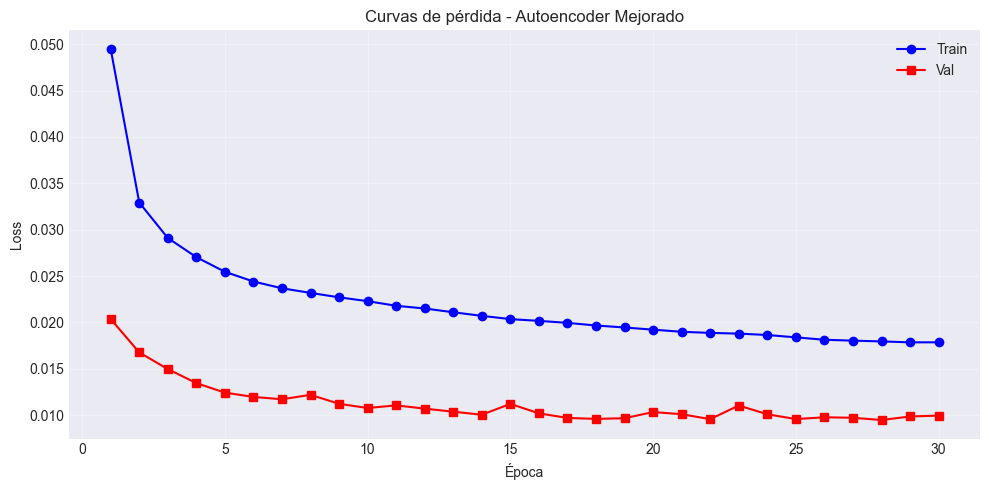

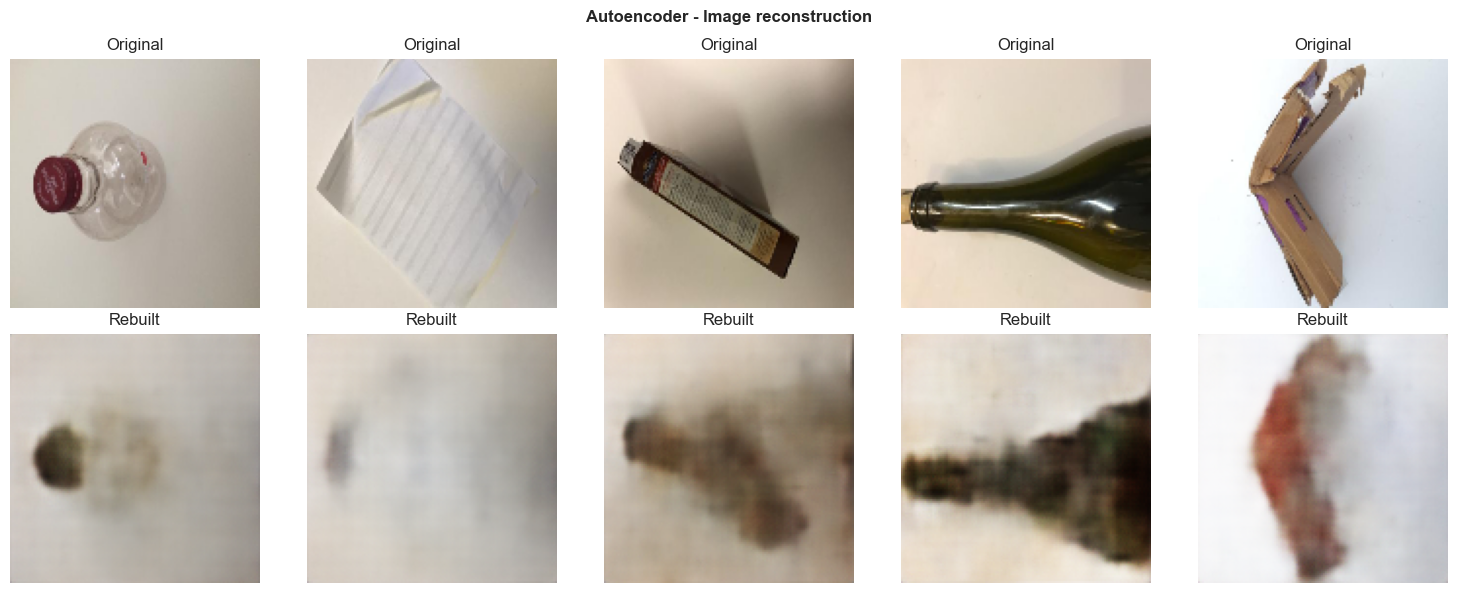


Extrayendo features...


Extrayendo features: 100%|██████████| 8/8 [00:00<00:00, 50.64it/s]


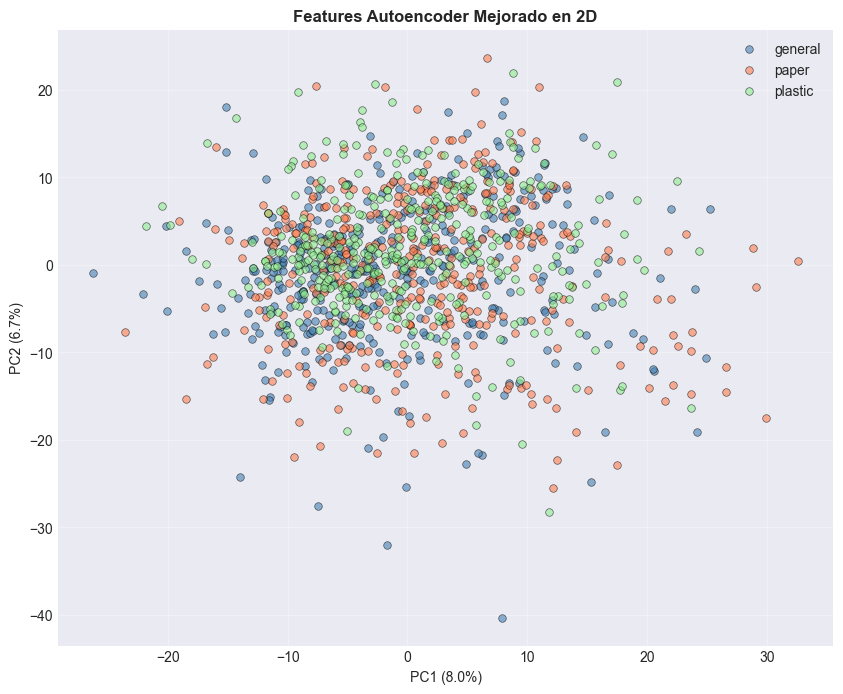

Features guardadas en e:\06. Sexto Ciclo\01. Machine Learning\07. Workspace\16S03. Proyecto 03\P3-EcoSort\result\features


In [10]:
resultados = extraer_features_ae_mejorado(
    X_train=X_train,
    X_val=X_val,
    y_train=y_train,  # Solo para visualización, NO entrena con esto
    y_val=y_val,
    clases=clases,
    latent_dim=980,
    epochs=30,
    lambda_var=0,  # Ajustar si necesitas más/menos dispersión
    guardar=True,
    ruta_features=ruta_features,
    ruta_figuras=ruta_figuras
)

#resultados_ae_vae = extraer_features_autoencoders_completo(
#    X_train=X_train,
#    X_val=X_val,
#    y_train=y_train,
#    y_val=y_val,
#    clases=clases,
#    model_type='variational',
#    latent_dim=128,
#    epochs=30,
#    batch_size=64,
#    learning_rate=0.0005,
#    guardar=True,
#    ruta_features=ruta_features,
#    ruta_figuras=ruta_figuras
#)



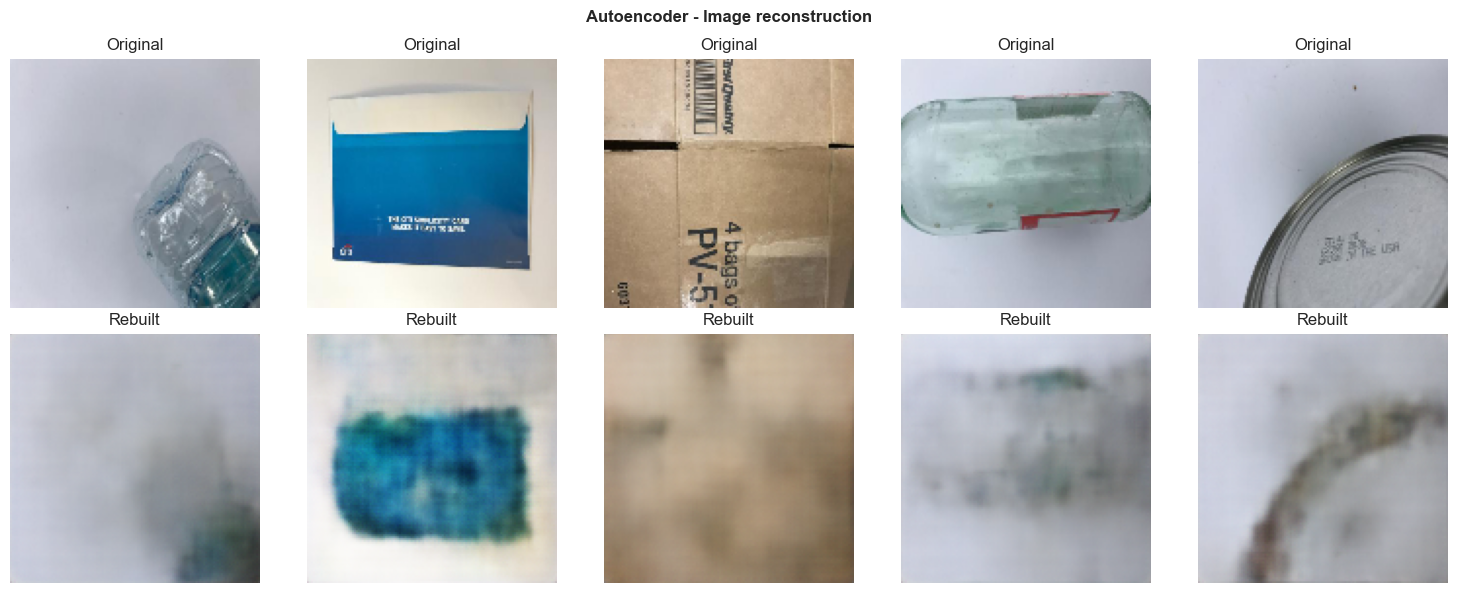

In [57]:
fig_recon = resultados['extractor'].visualize_reconstruction(X_val, n_samples=5)
if ruta_figuras:
    fig_recon.savefig(ruta_figuras / 'ae_mejorado_reconstruction.svg', bbox_inches='tight')
plt.show()
plt.close()


## 4. Fusión de características

### 4.1 Extracción y combinación de todas las características

In [ ]:
def extraer_todas_caracteristicas(imagenes):
    features_hog_lista = []
    features_color_lista = []
    
    for img in tqdm(imagenes, desc='Extrayendo características'):
        hog_feat = extraer_hog(img)
        color_feat = extraer_caracteristicas_color(img)
        
        features_hog_lista.append(hog_feat)
        features_color_lista.append(color_feat)
    
    features_hog = np.array(features_hog_lista)
    features_color = np.array(features_color_lista)
    features_combinadas = np.concatenate([features_hog, features_color], axis=1)
    
    return features_hog, features_color, features_combinadas

hog_train, color_train, features_train = extraer_todas_caracteristicas(X_train)
hog_val, color_val, features_val = extraer_todas_caracteristicas(X_val)

Extrayendo características: 100%|██████████| 507/507 [00:03<00:00, 165.30it/s]


In [ ]:
resumen_features = pd.DataFrame({
    'Tipo de característica': ['HOG', 'Color', 'Combinadas'],
    'Dimensiones Train': [hog_train.shape[1], color_train.shape[1], features_train.shape[1]],
    'Dimensiones Val': [hog_val.shape[1], color_val.shape[1], features_val.shape[1]]
})
resumen_features

,Tipo de característica,Dimensiones Train,Dimensiones Val
0,HOG,8100,8100
1,Color,297,297
2,Combinadas,8397,8397


### 4.2 Validación con Logistic Regression

In [ ]:
scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train)
features_val_scaled = scaler.transform(features_val)

modelo_logistic = LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial')
modelo_logistic.fit(features_train_scaled, y_train)

y_pred_train = modelo_logistic.predict(features_train_scaled)
y_pred_val = modelo_logistic.predict(features_val_scaled)

acc_train = accuracy_score(y_train, y_pred_train)
acc_val = accuracy_score(y_val, y_pred_val)

In [ ]:
validacion_resultados = pd.DataFrame({
    'Métrica': ['Accuracy Train', 'Accuracy Val'],
    'Valor': [f'{acc_train:.4f}', f'{acc_val:.4f}']
})
validacion_resultados

,Métrica,Valor
0,Accuracy Train,0.9999
1,Accuracy Val,0.6469


In [ ]:
reporte = classification_report(y_val, y_pred_val, target_names=clases, output_dict=True)
df_reporte = pd.DataFrame(reporte).transpose()
df_reporte = df_reporte.round(4)
df_reporte

,precision,recall,f1-score,support
general,0.6699,0.6667,0.6683,210.0000
paper,0.7717,0.7100,0.7396,200.0000
plastic,0.4035,0.4742,0.4360,97.0000
accuracy,0.6469,0.6469,0.6469,0.6469
macro avg,0.6150,0.6170,0.6146,507.0000
weighted avg,0.6591,0.6469,0.6520,507.0000


## 5. Reducción de dimensionalidad con PCA

### 5.1 Aplicación de PCA

In [ ]:
pca = PCA(n_components=0.95, random_state=42)
features_train_pca = pca.fit_transform(features_train_scaled)
features_val_pca = pca.transform(features_val_scaled)

varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)
num_componentes = pca.n_components_

In [ ]:
info_pca = pd.DataFrame({
    'Métrica': ['Dimensiones originales', 'Componentes PCA (95% varianza)', 'Varianza explicada', 'Reducción dimensionalidad'],
    'Valor': [
        features_train.shape[1],
        num_componentes,
        f'{varianza_acumulada[-1]:.4f}',
        f'{(1 - num_componentes/features_train.shape[1])*100:.2f}%'
    ]
})
info_pca

,Métrica,Valor
0,Dimensiones originales,8397
1,Componentes PCA (95% varianza),1933
2,Varianza explicada,0.9501
3,Reducción dimensionalidad,76.98%


### 5.2 Visualización de varianza explicada

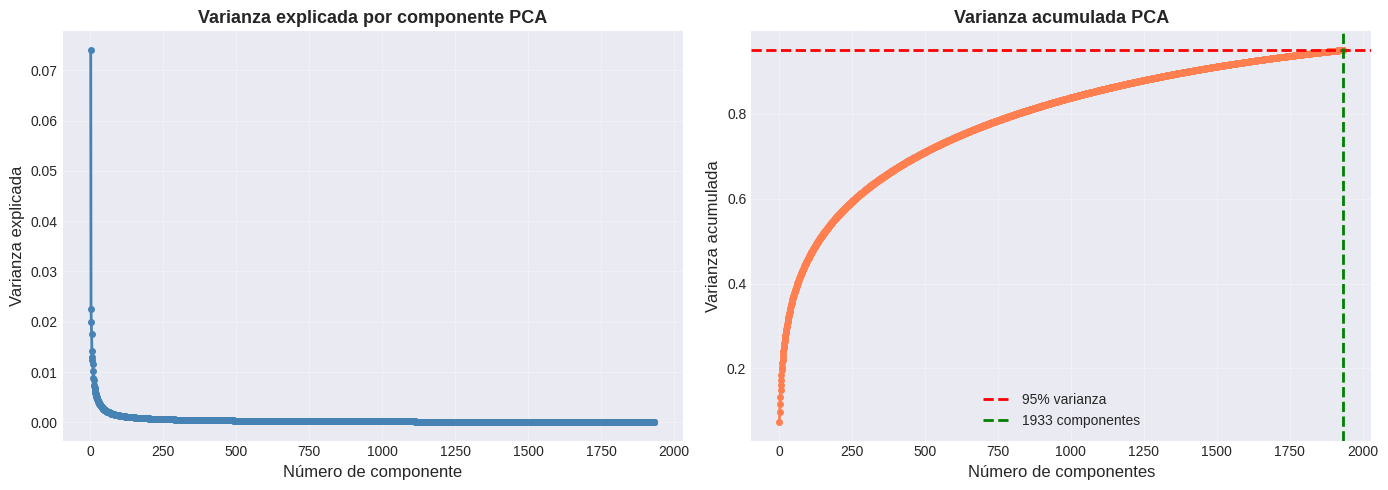

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'o-', linewidth=2, markersize=4, color='steelblue')
axes[0].set_xlabel('Número de componente', fontsize=12)
axes[0].set_ylabel('Varianza explicada', fontsize=12)
axes[0].set_title('Varianza explicada por componente PCA', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, 'o-', linewidth=2, markersize=4, color='coral')
axes[1].axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% varianza')
axes[1].axvline(x=num_componentes, color='green', linestyle='--', linewidth=2, label=f'{num_componentes} componentes')
axes[1].set_xlabel('Número de componentes', fontsize=12)
axes[1].set_ylabel('Varianza acumulada', fontsize=12)
axes[1].set_title('Varianza acumulada PCA', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ruta_figuras / '02_fe_05_pca_varianza.svg', format='svg', bbox_inches='tight')
plt.show()

### 5.3 Visualización de características PCA en 2D

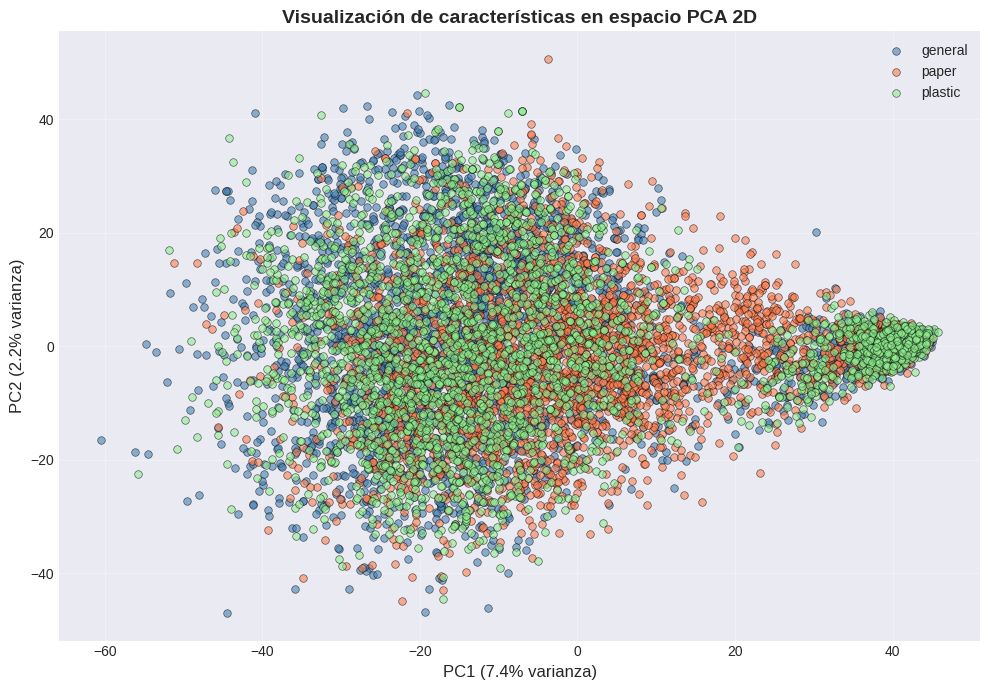

In [ ]:
pca_2d = PCA(n_components=2, random_state=42)
features_2d = pca_2d.fit_transform(features_train_scaled)

fig, ax = plt.subplots(figsize=(10, 7))

colores_plot = ['steelblue', 'coral', 'lightgreen']
for i, clase in enumerate(clases):
    indices = y_train == i
    ax.scatter(features_2d[indices, 0], features_2d[indices, 1], 
               alpha=0.6, label=clase, s=30, c=colores_plot[i], edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
ax.set_title('Visualización de características en espacio PCA 2D', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ruta_figuras / '02_fe_06_pca_2d_visualizacion.svg', format='svg', bbox_inches='tight')
plt.show()

## 6. Almacenamiento de características procesadas

In [ ]:
ruta_features.mkdir(parents=True, exist_ok=True)

np.save(ruta_features / 'X_train_imagenes.npy', X_train)
np.save(ruta_features / 'X_val_imagenes.npy', X_val)
np.save(ruta_features / 'y_train.npy', y_train)
np.save(ruta_features / 'y_val.npy', y_val)

np.save(ruta_features / 'features_train_combinadas.npy', features_train)
np.save(ruta_features / 'features_val_combinadas.npy', features_val)
np.save(ruta_features / 'features_train_pca.npy', features_train_pca)
np.save(ruta_features / 'features_val_pca.npy', features_val_pca)

joblib.dump(scaler, ruta_features / 'scaler.pkl')
joblib.dump(pca, ruta_features / 'pca_model.pkl')

['/home/zamirlm/Documents/Utec/Ciclo2025-2/ML-PROYECTOS/P3-EcoSort/result/features/pca_model.pkl']

In [ ]:
archivos_guardados = [
    'X_train_imagenes.npy',
    'X_val_imagenes.npy',
    'y_train.npy',
    'y_val.npy',
    'features_train_combinadas.npy',
    'features_val_combinadas.npy',
    'features_train_pca.npy',
    'features_val_pca.npy',
    'scaler.pkl',
    'pca_model.pkl'
]

resumen_archivos = pd.DataFrame({
    'Archivo': archivos_guardados,
    'Guardado': ['✓'] * len(archivos_guardados)
})
resumen_archivos

,Archivo,Guardado
0,X_train_imagenes.npy,✓
1,X_val_imagenes.npy,✓
2,y_train.npy,✓
3,y_val.npy,✓
4,features_train_combinadas.npy,✓
5,features_val_combinadas.npy,✓
6,features_train_pca.npy,✓
7,features_val_pca.npy,✓
8,scaler.pkl,✓
9,pca_model.pkl,✓


## Resumen del Feature Engineering

Se completaron exitosamente las siguientes etapas:

**1. Normalización y preprocesamiento:**
- Redimensionamiento a tamaño fijo de 128x128 píxeles
- Normalización de valores de píxeles a rango [0, 1]

**2. Data Augmentation:**
- Aplicación de 8 técnicas de augmentation diferentes
- Generación de dataset balanceado con mínimo 10,000 imágenes de entrenamiento
- Preservación de características realistas de los residuos

**3. Extracción de características:**
- HOG: Captura de patrones de forma y textura
- Color: Histogramas RGB, HSV, LAB y momentos de color
- Fusión exitosa de ambos tipos de características

**4. Reducción de dimensionalidad:**
- PCA aplicado para retener 95% de varianza
- Reducción significativa de dimensiones manteniendo información relevante

**5. Validación:**
- Modelo Logistic Regression simple confirma que las características son discriminativas
- Todas las matrices guardadas y listas para entrenamiento de modelos avanzados